## Metrics:
*AUROC*: It is the probability that a randomly chosen ID sample will have a higher "confidence score" than a randomly chosen OOD sample.

*FPR95*: If I want to save 95% of my real data, how much "garbage" is going to get into my system?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import re

In [6]:
def add_entropy_to_results(results):
    probs = results['probs']
    
    # Calculate Entropy: -sum(p * log(p))
    # axis=1 performs the sum across the classes for each sample
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    
    results['entropy'] = entropy
    
    # For AUROC functions that expect Higher = ID:
    # Use negative entropy (because we want ID to be the "higher" score)
    results['neg_entropy'] = -entropy
    
    return results

In [7]:
def add_energy_to_results(results, T=1.0):
    logits = torch.from_numpy(results['logits'])
    # Energy = -T * log(sum(exp(logit/T)))
    energy = -T * torch.logsumexp(logits / T, dim=1).numpy()
    results['energy'] = energy
    return results

In [8]:
def calculate_metrics(id_scores, ood_scores):
    """Calculates AUROC and FPR95 for a pair of score arrays."""
    # Ensure higher scores = In-Distribution for AUROC
    all_scores = np.concatenate([id_scores, ood_scores])
    thresholds = np.sort(np.unique(all_scores))[::-1]
    
    n_id, n_ood = len(id_scores), len(ood_scores)
    tpr_list, fpr_list = [], []

    for t in thresholds:
        tpr_list.append(np.sum(id_scores >= t) / n_id)
        fpr_list.append(np.sum(ood_scores >= t) / n_ood)

    auroc = np.trapz(tpr_list, fpr_list)
    
    threshold_95tpr = np.percentile(id_scores, 5)
    fpr95 = (np.sum(ood_scores >= threshold_95tpr) / n_ood) * 100

    threshold_90tpr = np.percentile(id_scores, 10)
    fpr90 = (np.sum(ood_scores >= threshold_90tpr) / n_ood) * 100
    
    return auroc, fpr95, fpr90

In [9]:
def run_ood_evaluation_workflow(dataset_names, score_types=None):
    """
    Standardized workflow to evaluate multiple OOD detection methods across multiple datasets.
    """
    if score_types is None:
        score_types = ['max_conf', 'max_logit', 'neg_entropy', 'neg_energy', 'odin_score', 'mahal_distance', 'knn_distance']
    
    master_results = []

    for data_name in dataset_names:
        print(f"--- Processing Dataset: {data_name} ---")
        
        # 1. Load Data using your specific naming convention
        # Note: We split the suffix to insert 'id' or 'ood' correctly
        id_path = f"../analysis_results/{data_name}_n3_h2_id_v4.npz"
        ood_path = f"../analysis_results/{data_name}_n3_h2_ood_v4.npz"
        
        try:
            id_data = dict(np.load(id_path))
            ood_data = dict(np.load(ood_path))
        except FileNotFoundError:
            print(f"Warning: Files not found for {data_name}. Skipping...")
            continue

        # 2. Preprocess / Calculate additional scores
        id_data = add_entropy_to_results(id_data)
        ood_data = add_entropy_to_results(ood_data)
        id_data = add_energy_to_results(id_data)
        ood_data = add_energy_to_results(ood_data)

        if 'logits' in id_data:
            id_data['max_logit'] = np.max(id_data['logits'], axis=1)
            ood_data['max_logit'] = np.max(ood_data['logits'], axis=1)
        
        # OOD metrics typically expect "Higher score = More likely to be ID"
        # Since Mahalanobis is a DISTANCE (Higher = OOD), we negate it for AUROC calculations.
        if 'mahal_distance' in id_data:
            id_data['neg_mahal'] = -id_data['mahal_distance']
            ood_data['neg_mahal'] = -ood_data['mahal_distance']
        
        if 'energy' in id_data:
            id_data['neg_energy'] = -id_data['energy']
            ood_data['neg_energy'] = -ood_data['energy']

        # 3. Calculate Metrics (AUROC, FPR95) for each method
        for score in score_types:
            # Map logical name to the actual key in the dictionary
            lookup_key = 'neg_mahal' if score == 'mahal_distance' else score
            
            if lookup_key not in id_data:
                continue

            auroc, fpr95, fpr90 = calculate_metrics(id_data[lookup_key], ood_data[lookup_key])
            
            master_results.append({
                'Dataset': data_name,
                'Method': score.replace('neg_', '').replace('_score', '').upper(),
                'AUROC': auroc,
                'FPR95': fpr95,
                'FPR90': fpr90
            })

    return pd.DataFrame(master_results)

In [15]:
def run_full_ood_evaluation_workflow(id_file, ood_files, score_types=None):
    """
    Evaluate one ID dataset against multiple OOD datasets.
    
    Parameters:
        id_file (str): Full filename of ID dataset
        ood_files (list): List of full filenames for OOD datasets
    """
    if score_types is None:
        score_types = [
            'max_conf', 'max_logit', 'neg_entropy',
            'neg_energy', 'odin_score', 'mahal_distance', 'knn_distance'
        ]

    master_results = []

    print(f"--- Loading ID Dataset: {id_file} ---")

    try:
        id_data = dict(np.load(id_file))
    except FileNotFoundError:
        raise ValueError(f"ID dataset not found: {id_file}")

    # 🔧 Precompute ID features
    id_data = add_entropy_to_results(id_data)
    id_data = add_energy_to_results(id_data)

    if 'logits' in id_data:
        id_data['max_logit'] = np.max(id_data['logits'], axis=1)

    if 'mahal_distance' in id_data:
        id_data['neg_mahal'] = -id_data['mahal_distance']

    if 'energy' in id_data:
        id_data['neg_energy'] = -id_data['energy']

    # 🔁 Loop over OOD datasets
    for ood_file in ood_files:
        print(f"--- Evaluating: {ood_file} ---")

        try:
            ood_data = dict(np.load(ood_file))
        except FileNotFoundError:
            print(f"Warning: File not found: {ood_file}")
            continue

        # Extract readable name (clean label)
        match = re.search(r'ood\d*', ood_file.lower())
        ood_name = match.group() if match else "unknown"

        # 🔧 Preprocess OOD
        ood_data = add_entropy_to_results(ood_data)
        ood_data = add_energy_to_results(ood_data)

        if 'logits' in ood_data:
            ood_data['max_logit'] = np.max(ood_data['logits'], axis=1)

        if 'mahal_distance' in ood_data:
            ood_data['neg_mahal'] = -ood_data['mahal_distance']

        if 'energy' in ood_data:
            ood_data['neg_energy'] = -ood_data['energy']

        # 🔬 Evaluate
        for score in score_types:
            lookup_key = 'neg_mahal' if score == 'mahal_distance' else score

            if lookup_key not in id_data or lookup_key not in ood_data:
                continue

            auroc, fpr95, fpr90 = calculate_metrics(
                id_data[lookup_key],
                ood_data[lookup_key]
            )

            master_results.append({
                'Dataset': ood_name,
                'Method': score.replace('neg_', '').replace('_score', '').upper(),
                'AUROC': auroc,
                'FPR95': fpr95,
                'FPR90': fpr90
            })

    return pd.DataFrame(master_results)

In [16]:
def plot_comparison_report(df):
    # 1. Prepare data structures for Matplotlib
    datasets = df['Dataset'].unique()
    methods = df['Method'].unique()
    
    n_datasets = len(datasets)
    n_methods = len(methods)
    
    # Set the width of each bar and the positions on the X-axis
    width = 0.8 / n_methods  # Total width of 0.8 shared by all bars in a group
    x_indices = np.arange(n_datasets)
    
    # Define a color palette
    colors = plt.cm.tab10(np.linspace(0, 1, n_methods))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 2. Loop through methods to plot each bar set
    for i, method in enumerate(methods):
        method_data = df[df['Method'] == method]
        
        # Calculate offset for the current method's bars
        # This centers the group of bars over the tick mark
        offset = (i - (n_methods - 1) / 2) * width
        
        # Plot AUROC
        ax1.bar(x_indices + offset, method_data['AUROC'], width, 
                label=method, color=colors[i], edgecolor='black', alpha=0.8)
        
        # Plot FPR95
        ax2.bar(x_indices + offset, method_data['FPR95'], width, 
                label=method, color=colors[i], edgecolor='black', alpha=0.8)

    # 3. Formatting AUROC (Subplot 1)
    ax1.set_title("AUROC Comparison (Higher is Better)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("AUROC Score", fontsize=12)
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(datasets)
    ax1.set_ylim(0.0, 1.0)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)
    ax1.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')

    # 4. Formatting FPR95 (Subplot 2)
    ax2.set_title("FPR at 95% TPR (Lower is Better)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("FPR95 (%)", fontsize=12)
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(datasets)
    ax2.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [20]:
# Execute Workflow
datasets = ["WISDM", "HAR"]
report_df = run_ood_evaluation_workflow(datasets)

--- Processing Dataset: WISDM ---
--- Processing Dataset: HAR ---


In [23]:
report_df

,Dataset,Method,AUROC,FPR95,FPR90
0,WISDM,MAX_CONF,0.799734,84.750733,65.982405
1,WISDM,MAX_LOGIT,0.737555,86.803519,75.659824
2,WISDM,ENTROPY,0.782102,84.164223,72.727273
3,WISDM,ENERGY,0.711592,91.202346,83.284457
4,WISDM,ODIN,0.756264,80.645161,68.328446
5,WISDM,MAHAL_DISTANCE,0.793850,74.193548,53.372434
6,WISDM,KNN_DISTANCE,0.333029,98.826979,96.187683
7,HAR,MAX_CONF,0.673063,92.323031,85.443669
8,HAR,MAX_LOGIT,0.767073,84.147557,67.996012
9,HAR,ENTROPY,0.677931,92.323031,84.546361


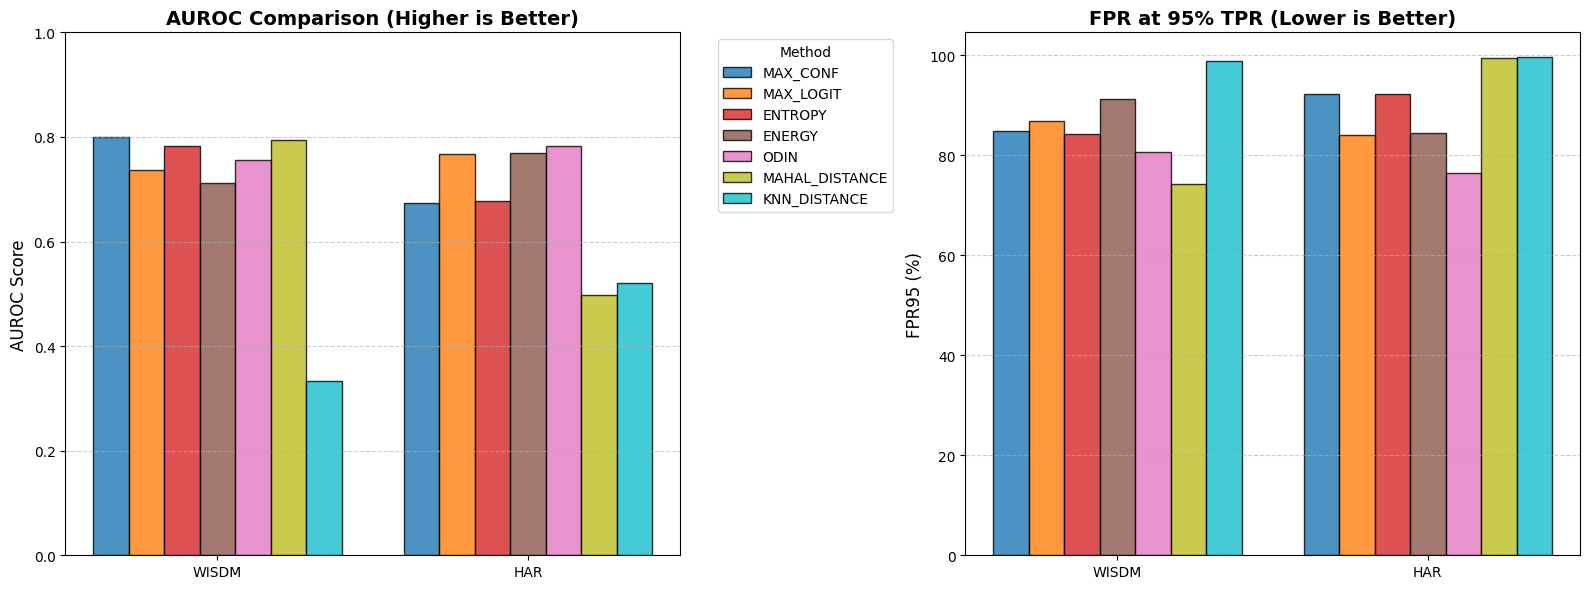

In [22]:
plot_comparison_report(report_df)

In [17]:
id_file = "../analysis_results/HAR_n3_h2_id_change_experiment.npz"

ood_files = [
    "../analysis_results/HAR_n3_h2_ood_change_experiment.npz",
    "../analysis_results/HAR_n3_h2_ood1_change_experiment.npz",
    "../analysis_results/HAR_n3_h2_ood2_change_experiment.npz",
    "../analysis_results/HAR_n3_h2_ood3_change_experiment.npz",
    "../analysis_results/HAR_n3_h2_ood4_change_experiment.npz",
]

df_results = run_full_ood_evaluation_workflow(id_file, ood_files)

--- Loading ID Dataset: ../analysis_results/HAR_n3_h2_id_change_experiment.npz ---
--- Evaluating: ../analysis_results/HAR_n3_h2_ood_change_experiment.npz ---
--- Evaluating: ../analysis_results/HAR_n3_h2_ood1_change_experiment.npz ---
--- Evaluating: ../analysis_results/HAR_n3_h2_ood2_change_experiment.npz ---
--- Evaluating: ../analysis_results/HAR_n3_h2_ood3_change_experiment.npz ---
--- Evaluating: ../analysis_results/HAR_n3_h2_ood4_change_experiment.npz ---


In [18]:
df_results

,Dataset,Method,AUROC,FPR95,FPR90
0,HAR_n3_h2_ood_change_experiment,MAX_CONF,0.673063,92.323031,85.443669
1,HAR_n3_h2_ood_change_experiment,MAX_LOGIT,0.767073,84.147557,67.996012
2,HAR_n3_h2_ood_change_experiment,ENTROPY,0.677931,92.323031,84.546361
3,HAR_n3_h2_ood_change_experiment,ENERGY,0.768980,84.546361,68.394816
4,HAR_n3_h2_ood_change_experiment,ODIN,0.782793,76.370887,61.914257
5,HAR_n3_h2_ood_change_experiment,MAHAL_DISTANCE,0.497579,99.401795,98.404786
6,HAR_n3_h2_ood_change_experiment,KNN_DISTANCE,0.520849,99.601196,98.005982
7,HAR_n3_h2_ood1_change_experiment,MAX_CONF,0.778187,85.643071,74.177468
8,HAR_n3_h2_ood1_change_experiment,MAX_LOGIT,0.690936,93.320040,77.766700
9,HAR_n3_h2_ood1_change_experiment,ENTROPY,0.777904,86.141575,72.781655


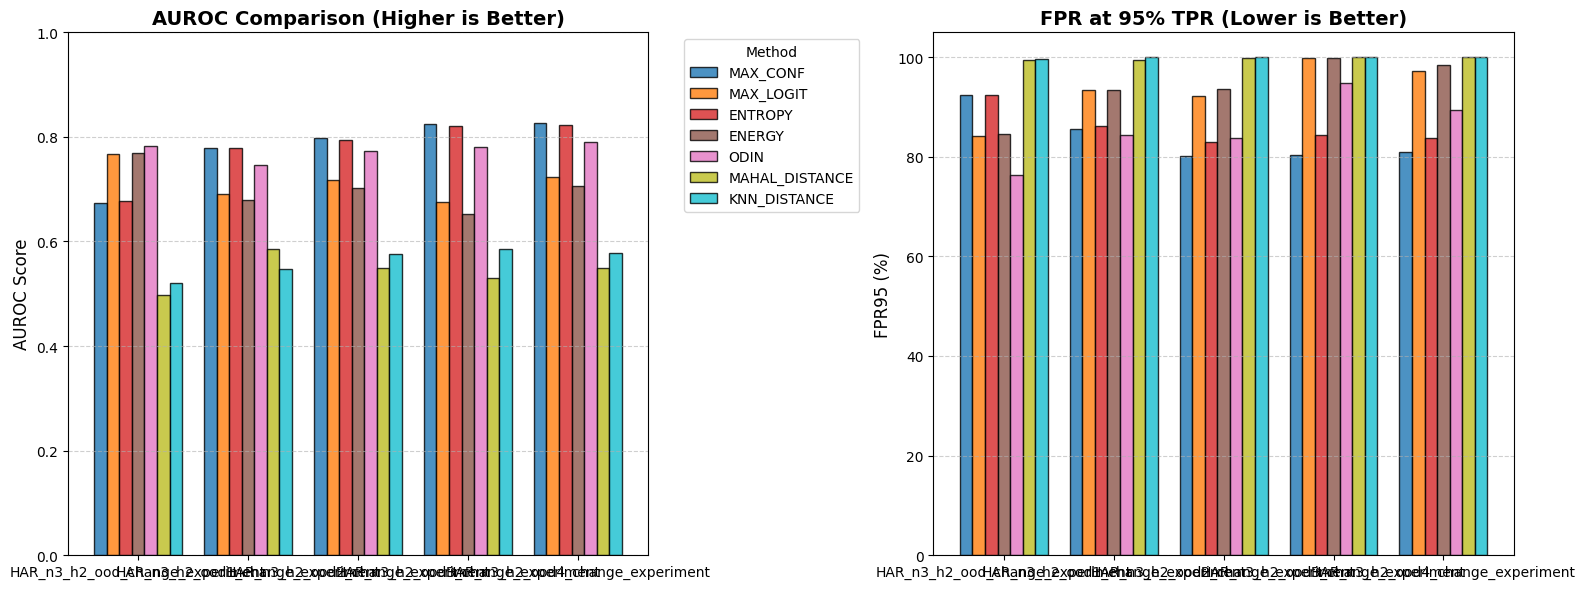

In [19]:
plot_comparison_report(df_results)